# CRISPR-Cas Atlas Summary

In [2]:
import modules.atlas_handle as ah
from Bio import SeqIO
import sys, os, re
import pandas as pd
import logomaker
import modules.analysis_utils as analysis_utils
from IPython.display import display
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous, geom_vline, 
                      geom_boxplot, geom_jitter, scale_x_discrete, stat_summary,
                      scale_y_continuous, scale_fill_manual, scale_color_manual, geom_hline,
                      element_blank)
import matplotlib.pyplot as plt
import numpy as np
import typing as t
from Bio.Seq import Seq
import json
import statistics
from upsetplot import UpSet, from_indicators

## Operon length

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
I,26570.0,11017.702446,4200.617203,380.0,9162.0,10795.5,12848.0,84283.0
II,7962.0,7376.167420,2017.331183,819.0,6165.0,7136.0,8409.0,23707.0
III,5133.0,13117.487824,5370.894825,501.0,9767.0,12873.0,15750.0,75765.0
IV,407.0,5851.653563,2446.123880,1090.0,4253.0,5952.0,6938.5,24126.0
Unknown,6211.0,3368.624054,2275.885177,345.0,1797.5,2898.0,4252.0,24070.0
V,1456.0,4720.975962,2973.553261,1224.0,2589.0,3716.5,6361.0,26413.0
VI,435.0,4986.321839,1192.986160,3082.0,4504.0,4755.0,5000.0,15027.0


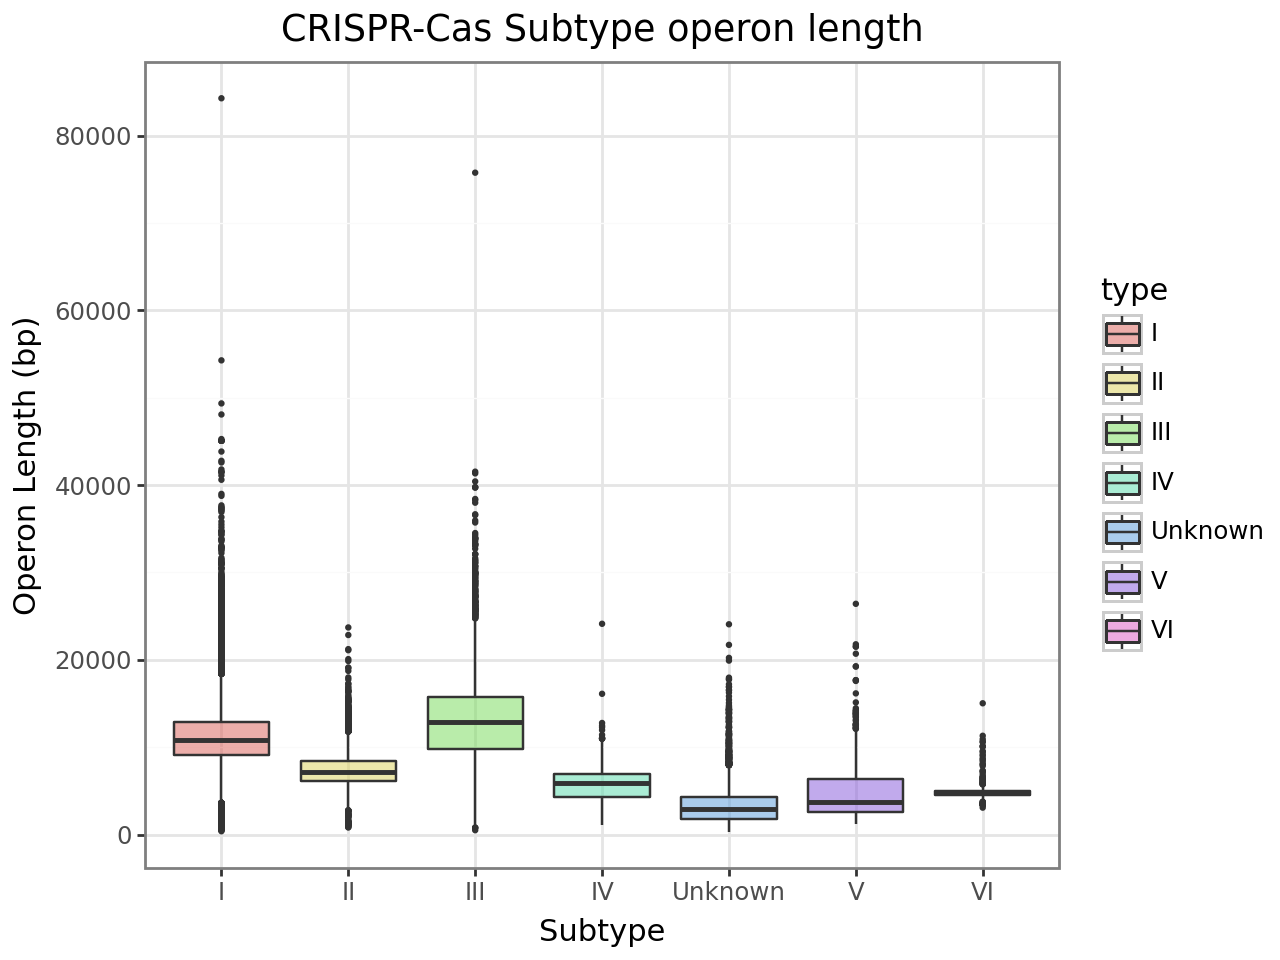

In [3]:
operon_length_file = "atlas_summary/atlas_operon_length_distribution.csv"

operon_length_df = pd.read_csv(operon_length_file, header=0)

stats = operon_length_df.groupby('type')['length'].describe()
display(stats)

p = (
    ggplot(operon_length_df, aes(x='type', y='length', fill='type')) +
    geom_boxplot(alpha=0.5, outlier_size=0.3) +
    theme_bw() +
    labs(
        title="CRISPR-Cas Subtype operon length",
        x="Subtype",
        y="Operon Length (bp)"
    )
)

display(p)

/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

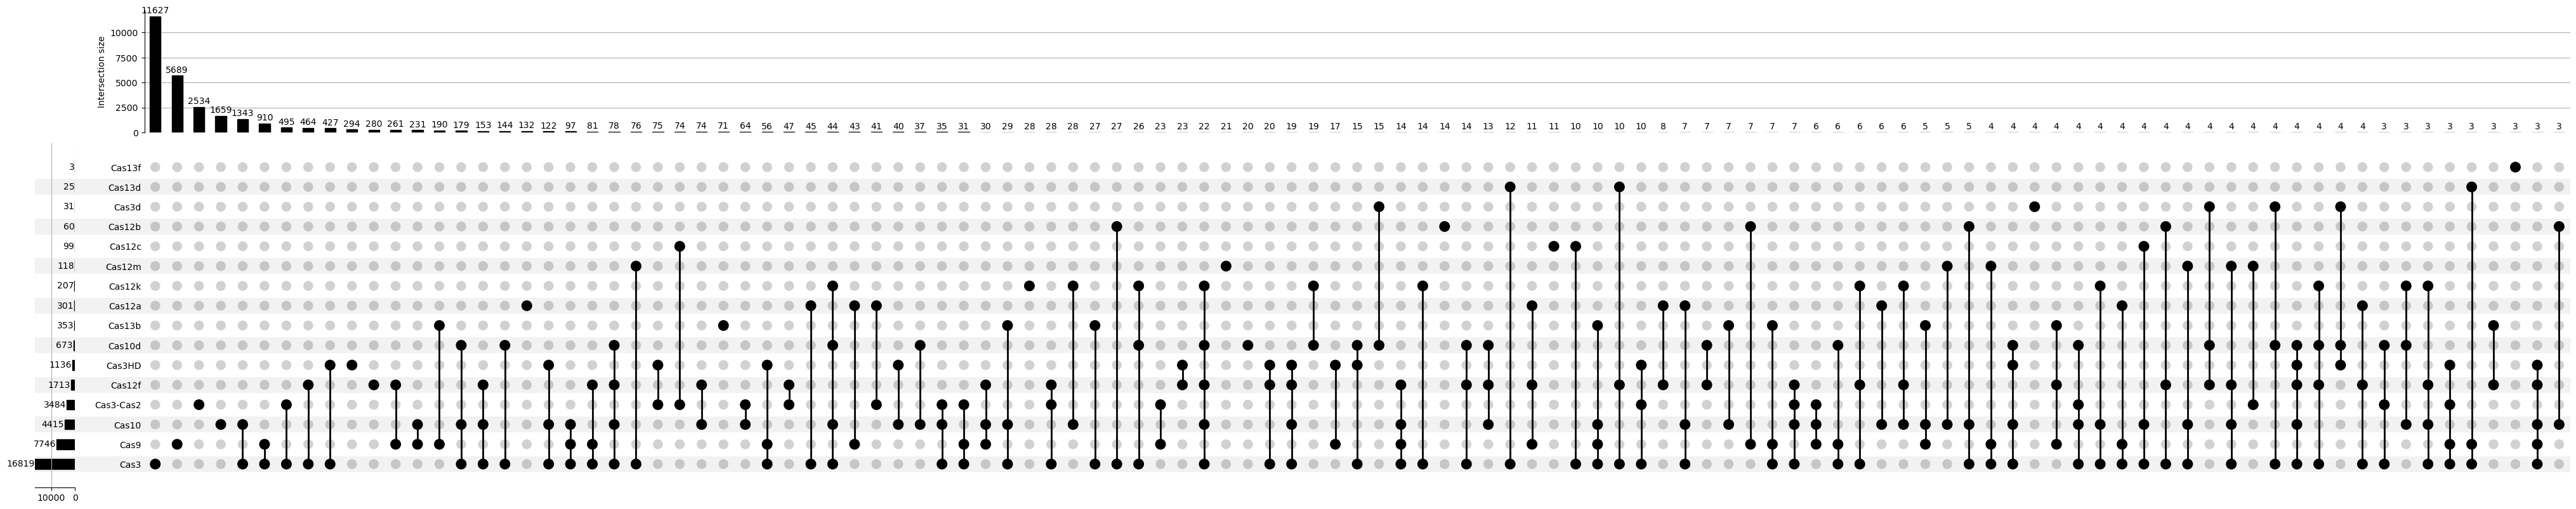

In [ ]:
# draw upset

upset_input_file = "atlas_summary/upset_input.csv"

upset_df = pd.read_csv(upset_input_file, header=0)
upset_df = upset_df.drop(upset_df.columns[0], axis=1)


# display(upset_df.head())
row_counts = upset_df.groupby(upset_df.columns.tolist()).size()

# Identify combinations that occur > 2
valid_combos = row_counts[row_counts > 2].index

# Filter df to keep only rows with >2 repeats
filtered_df = upset_df[upset_df.apply(tuple, axis=1).isin(valid_combos)]


indicator_cols = upset_df.columns.tolist()
df = filtered_df[indicator_cols].astype(bool)

# min_size = 1

# df_filtered = df[df.sum(axis=1) > min_size]

# Build UpSet data from boolean indicator columns
data = from_indicators(df)

# # keep only intersections that occur > 1 time
# tmp_data = data[data > 1]


upset = UpSet(data, 
              subset_size='count', 
              sort_by='cardinality',
              show_counts=True)
upset.plot()
plt.show()

output_file = f"atlas_summary/upset_plot.png"
upset.plot()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()